# Exploratory Data Analysis — Hotel Cancellation Data


## Goal

Understand the structure, distributions, and predictive signal in the booking data
*before* modeling

This notebook reads the cleaned/encoded output of `data-processing.ipynb`


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

In [2]:
df = pd.read_csv("../data/processed/processed_data.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,arrival_date_month_December,arrival_date_month_February,arrival_date_month_January,arrival_date_month_July,arrival_date_month_June,arrival_date_month_March,arrival_date_month_May,arrival_date_month_November,arrival_date_month_October,arrival_date_month_September
0,0,0,342,2015,27,1,0,0,2,0,...,0,0,0,1,0,0,0,0,0,0
1,0,0,737,2015,27,1,0,0,2,0,...,0,0,0,1,0,0,0,0,0,0
2,0,0,7,2015,27,1,0,1,1,0,...,0,0,0,1,0,0,0,0,0,0
3,0,0,13,2015,27,1,0,1,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,0,14,2015,27,1,0,2,2,0,...,0,0,0,1,0,0,0,0,0,0


## 1. Distribution Analysis (patterns & skewness)

Examine how the key features are distributed to spot skew, long tails, and dominant categories.

Numeric feature summary:

       lead_time        adr  stays_in_week_nights  stays_in_weekend_nights  previous_cancellations  booking_changes  total_of_special_requests  days_in_waiting_list
count  119209.00  119209.00              119209.0                119209.00               119209.00        119209.00                  119209.00             119209.00
mean      104.11     101.92                   2.5                     0.93                    0.09             0.22                       0.57                  2.32
std       106.88      48.04                   1.9                     1.00                    0.84             0.64                       0.79                 17.60
min         0.00      -6.38                   0.0                     0.00                    0.00             0.00                       0.00                  0.00
25%        18.00      69.50                   1.0                     0.00                    0.00             0.00                       0.00       

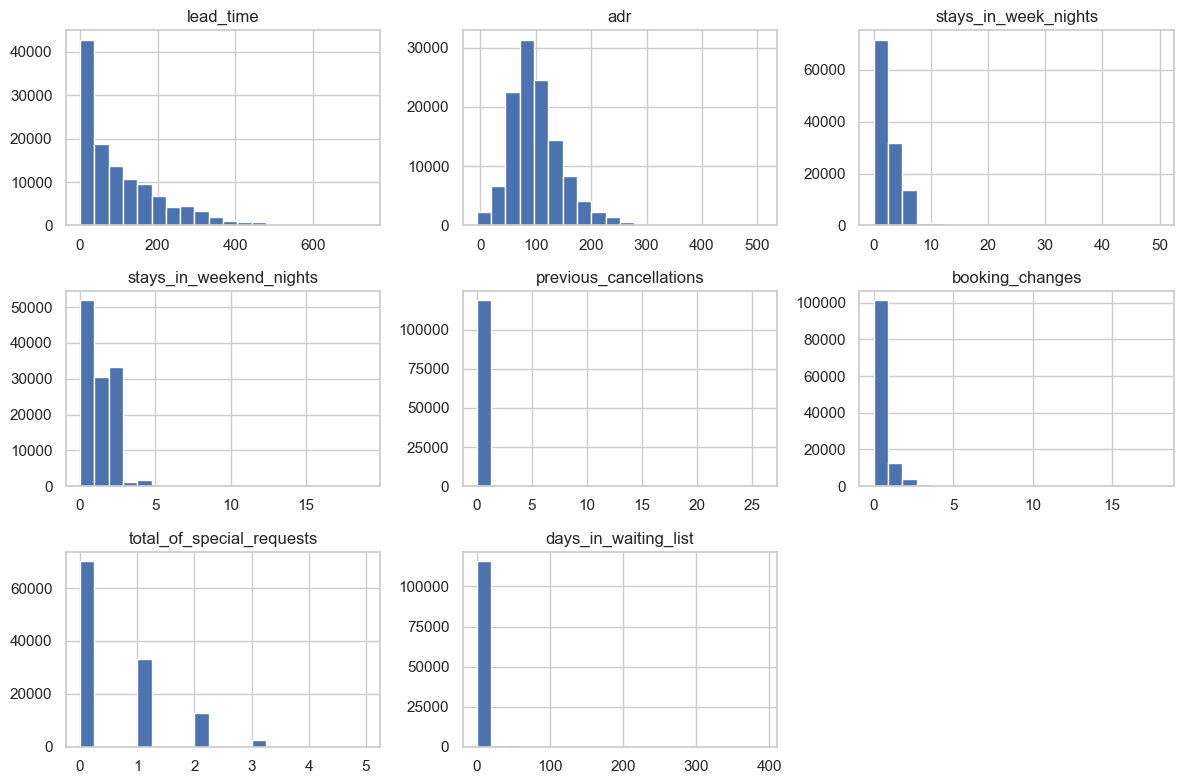

In [3]:
num_cols = [
    "lead_time", "adr", "stays_in_week_nights", "stays_in_weekend_nights",
    "previous_cancellations", "booking_changes", "total_of_special_requests", "days_in_waiting_list",
]

print("Numeric feature summary:\n")
print(df[num_cols].describe().round(2).to_string())
print("\nSkewness (high positive = right-skewed):")
print(df[num_cols].skew().round(2).sort_values(ascending=False).to_string())

df[num_cols].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

In [4]:
def from_onehot(frame, prefix, baseline):
    s = pd.Series(baseline, index=frame.index)
    for c in [c for c in frame.columns if c.startswith(prefix)]:
        s = s.mask(frame[c] == 1, c[len(prefix):])
    return s

df["hotel"] = df["hotel"].map({1: "City Hotel", 0: "Resort Hotel"})
df["deposit_type"] = from_onehot(df, "deposit_type_", "No Deposit")
df["customer_type"] = from_onehot(df, "customer_type_", "Contract")
df["distribution_channel"] = from_onehot(df, "distribution_channel_", "Corporate")
df["repeated_guest"] = df["is_repeated_guest"].map({0: "No", 1: "Yes"})
categorical_cols = ["hotel", "deposit_type", "customer_type", "distribution_channel", "repeated_guest"]

print("Categorical feature counts (sorted by frequency):\n")
for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts().to_string())
    print()

Categorical feature counts (sorted by frequency):

--- hotel ---
hotel
City Hotel      79162
Resort Hotel    40047

--- deposit_type ---
deposit_type
No Deposit    104461
Non Refund     14586
Refundable       162

--- customer_type ---
customer_type
Transient          89475
Transient-Party    25088
Contract            4072
Group                574

--- distribution_channel ---
distribution_channel
TA/TO        97749
Direct       14611
Corporate     6651
GDS            193
Undefined        5

--- repeated_guest ---
repeated_guest
No     115454
Yes      3755



## 2. Feature vs. Target Relationships & Insights

We now look at how each feature relates to `is_canceled`

Cancellation rate by category (overall = 37.1%)

--- hotel ---
hotel
City Hotel      0.418
Resort Hotel    0.278

--- deposit_type ---
deposit_type
Non Refund    0.994
No Deposit    0.284
Refundable    0.222

--- customer_type ---
customer_type
Transient          0.408
Contract           0.310
Transient-Party    0.255
Group              0.101

--- distribution_channel ---
distribution_channel
Undefined    0.800
TA/TO        0.411
Corporate    0.221
GDS          0.192
Direct       0.175

--- repeated_guest ---
repeated_guest
No     0.378
Yes    0.146



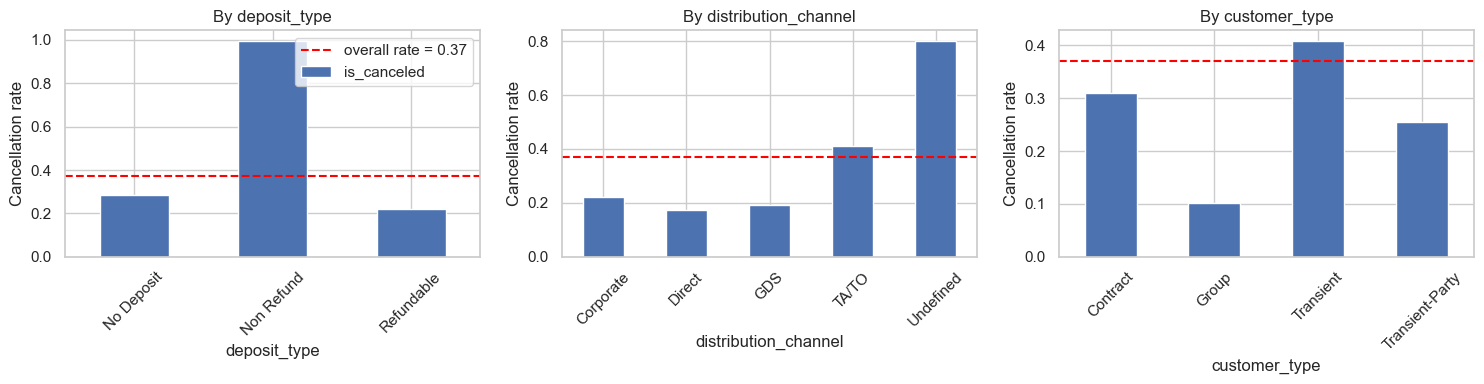

In [5]:
overall_rate = df["is_canceled"].mean()
print(f"Cancellation rate by category (overall = {overall_rate:.1%})\n")
for col in categorical_cols:
    print(f"--- {col} ---")
    print(df.groupby(col)["is_canceled"].mean().sort_values(ascending=False).round(3).to_string())
    print()


overall_rate = df['is_canceled'].mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df.groupby('deposit_type')['is_canceled'].mean().plot(kind='bar', ax=axes[0], rot=45)
axes[0].set_title('By deposit_type')
df.groupby('distribution_channel')['is_canceled'].mean().plot(kind='bar', ax=axes[1], rot=45)
axes[1].set_title('By distribution_channel')
df.groupby('customer_type')['is_canceled'].mean().plot(kind='bar', ax=axes[2], rot=45)
axes[2].set_title('By customer_type')

for ax in axes:
    ax.axhline(overall_rate, color='red', linestyle='--', label=f'overall rate = {overall_rate:.2f}')
    ax.set_ylabel('Cancellation rate')

axes[0].legend()

plt.tight_layout()
plt.show()

In [6]:
bins = [-1, 7, 30, 90, np.inf]
labels = ["0-7", "8-30", "31-90", "90+"]
bucket_rate = df.groupby(pd.cut(df["lead_time"], bins=bins, labels=labels), observed=True)["is_canceled"].mean()

print(f"Cancellation rate by lead-time bucket (overall = {overall_rate:.1%}):\n")
print(bucket_rate.round(3).to_string())


Cancellation rate by lead-time bucket (overall = 37.1%):

lead_time
0-7      0.096
8-30     0.279
31-90    0.377
90+      0.507


# 3.Correlation Analysis

How numeric features relate to `is_canceled` and to each other.

Correlation matrix (Pearson, rounded to 2 dp):

                                is_canceled  lead_time   adr  total_of_special_requests  required_car_parking_spaces  booking_changes  previous_cancellations  previous_bookings_not_canceled  days_in_waiting_list  is_repeated_guest  stays_in_week_nights  stays_in_weekend_nights  total_nights  adults
is_canceled                            1.00       0.29  0.05                      -0.23                        -0.20            -0.14                    0.11                           -0.06                  0.05              -0.08                  0.03                    -0.00          0.02    0.06
lead_time                              0.29       1.00 -0.07                      -0.10                        -0.12             0.00                    0.09                           -0.07                  0.17              -0.12                  0.17                     0.09          0.16    0.12
adr                                    0.05      -0.

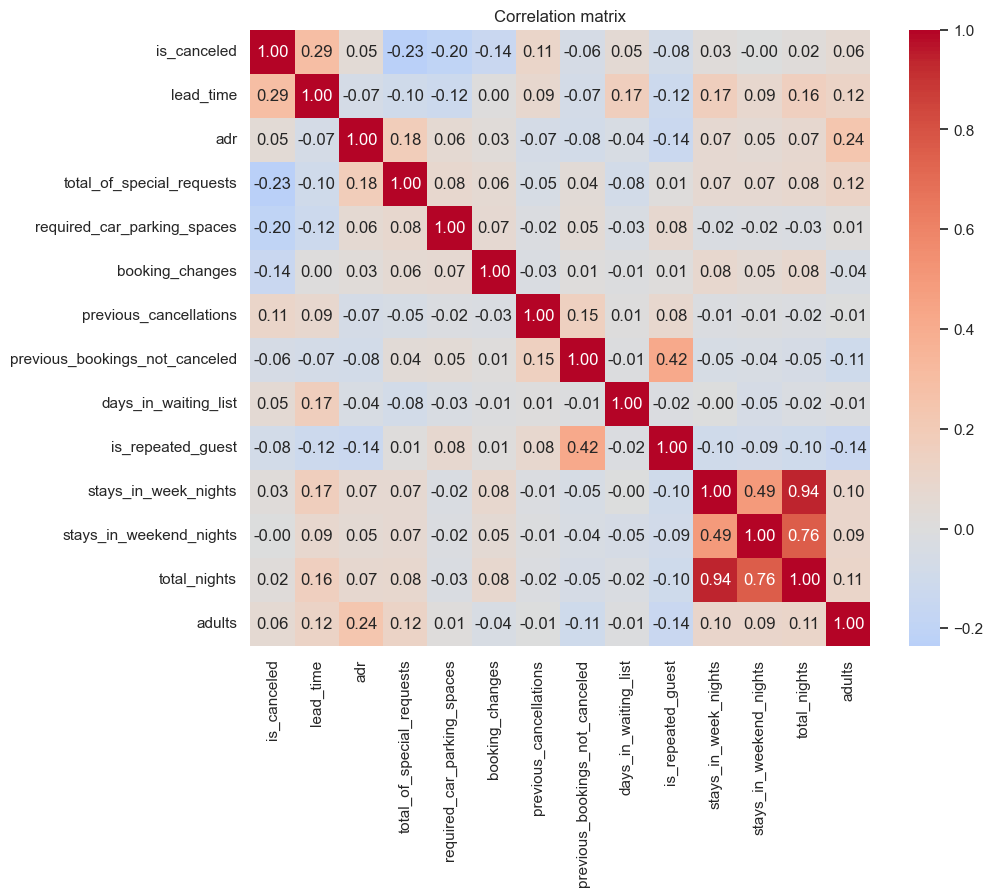

In [7]:
heat_cols = [
    "is_canceled", "lead_time", "adr", "total_of_special_requests", "required_car_parking_spaces",
    "booking_changes", "previous_cancellations", "previous_bookings_not_canceled", "days_in_waiting_list",
    "is_repeated_guest", "stays_in_week_nights", "stays_in_weekend_nights", "total_nights", "adults",
]
corr = df[heat_cols].corr()

print("Correlation matrix (Pearson, rounded to 2 dp):\n")
print(corr.round(2).to_string())

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.show()

In [8]:
target_corr = (
    df.select_dtypes("number")
      .drop(columns=["is_canceled", "lead_time_log", "adr_log"])
      .corrwith(df["is_canceled"])
)
top = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index).head(15)

print("Top 15 features by |correlation| with is_canceled:\n")
print(top.round(3).to_string())

Top 15 features by |correlation| with is_canceled:

deposit_type_Non Refund           0.481
country_encoded                   0.324
lead_time                         0.293
room_mismatch                    -0.247
total_of_special_requests        -0.235
required_car_parking_spaces      -0.196
distribution_channel_TA/TO        0.176
distribution_channel_Direct      -0.152
booking_changes                  -0.145
customer_type_Transient           0.133
customer_type_Transient-Party    -0.124
previous_cancellations            0.110
is_repeated_guest                -0.084
adults                            0.058
previous_bookings_not_canceled   -0.057


## 4. Time-Based Patterns
We reconstruct `arrival_date_month` from its one-hot columns (April was dropped as the baseline), then plot rates and volumes in calendar order.

Cancellation rate by arrival month (overall = 37.1%):

arrival_month
January      0.305
February     0.334
March        0.322
April        0.408
May          0.397
June         0.415
July         0.375
August       0.378
September    0.392
October      0.381
November     0.313
December     0.350


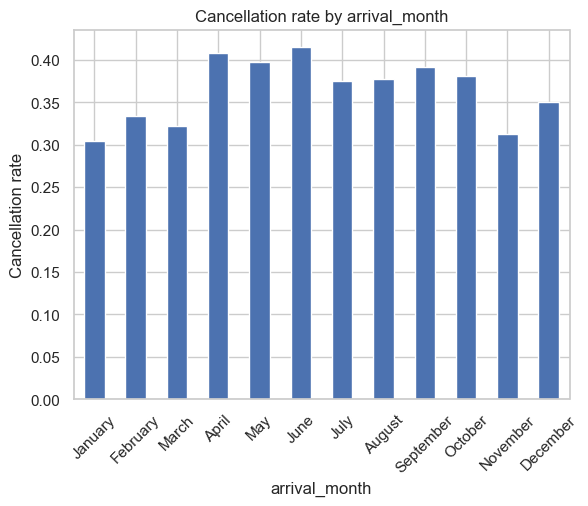

In [9]:
df["arrival_month"] = from_onehot(df, "arrival_date_month_", "April")

month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
month_rate = df.groupby("arrival_month")["is_canceled"].mean().reindex(month_order)

print(f"Cancellation rate by arrival month (overall = {overall_rate:.1%}):\n")
print(month_rate.round(3).to_string())

month_rate.plot(kind='bar', rot=45, title='Cancellation rate by arrival_month')
plt.ylabel('Cancellation rate')
plt.show()

## 5. Feature Importance Assessment

We use mutual information (`mutual_info_classif`) to rank every feature by how much predictive signal it carries about `is_canceled`.

Feature importance by mutual information (top 15):

deposit_type_Non Refund        0.1335
lead_time                      0.0830
adr                            0.0808
country_encoded                0.0725
previous_cancellations         0.0396
room_mismatch                  0.0391
total_of_special_requests      0.0376
required_car_parking_spaces    0.0309
distribution_channel_TA/TO     0.0276
customer_type_Transient        0.0212
booking_changes                0.0188
total_nights                   0.0149
days_in_waiting_list           0.0147
total_guests                   0.0145
distribution_channel_Direct    0.0128


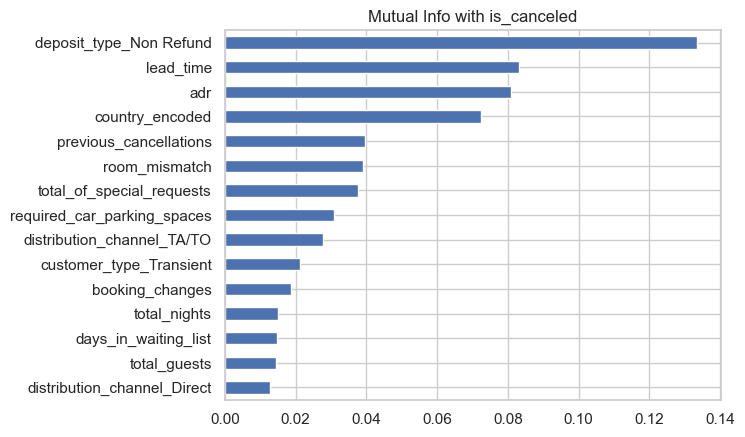

In [10]:
from sklearn.feature_selection import mutual_info_classif

feature_cols = [c for c in df.select_dtypes("number").columns
                if c not in ("is_canceled", "lead_time_log", "adr_log")]

X = df[feature_cols].fillna(0)
y = df["is_canceled"]

mi_scores = mutual_info_classif(X, y, random_state=42)
mi = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

print("Feature importance by mutual information (top 15):\n")
print(mi.head(15).round(4).to_string())

mi.head(15).sort_values().plot(kind='barh', title='Mutual Info with is_canceled')
plt.show()

## 6. Insights Summary

Baseline cancellation rate: **37.1%**

- **`deposit_type_Non Refund`** has a 99.4% cancel rate — the single strongest predictor (r = 0.48). 
- **`lead_time`** cancel rate rises from 9.6% (0–7 days) to 50.7% (90+ days). Median lead time: 45 days for stayed vs. 113 days for cancelled.
- **`country_encoded`** is the second-strongest positive predictor (r = 0.32) — consider country-level risk tiers.
- **Engagement features protect:** `total_of_special_requests` (r = −0.24), `required_car_parking_spaces` (r = −0.20), and `booking_changes` (r = −0.15) all lower cancel risk.
- **Repeat guests** cancel at 14.6% vs. 37.8% for first-time guests
- **Seasonality:** Spring/early summer cancels most (June 41.5%, April 40.8%); winter cancels least (January 30.5%, November 31.3%).
- **Redundant features to drop:** `total_nights` = week + weekend nights; `lead_time_log`/`adr_log` duplicate their raw counterparts